In [1]:
import pandas as pd

fake = pd.read_csv('../data/Fake.csv')
real = pd.read_csv('../data/True.csv')

print("Fake shape:", fake.shape)
print("Real shape:", real.shape)
fake.head()

Fake shape: (23481, 4)
Real shape: (21417, 4)


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [2]:
fake['label'] = 0  
real['label'] = 1  

df = pd.concat([fake, real], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

df.shape
df['label'].value_counts()
df.isnull().sum()
df.duplicated().sum()

np.int64(209)

In [3]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(44689, 5)

In [4]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)      # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)             # remove punctuation/numbers
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\om.ak\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\om.ak\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,text,clean_text
0,"21st Century Wire says Ben Stein, reputable pr...",st century wire say ben stein reputable profes...
1,WASHINGTON (Reuters) - U.S. President Donald T...,washington reuters u president donald trump re...
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,reuters puerto rico governor ricardo rossello ...
3,"On Monday, Donald Trump once again embarrassed...",monday donald trump embarrassed country accide...
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",glasgow scotland reuters u presidential candid...


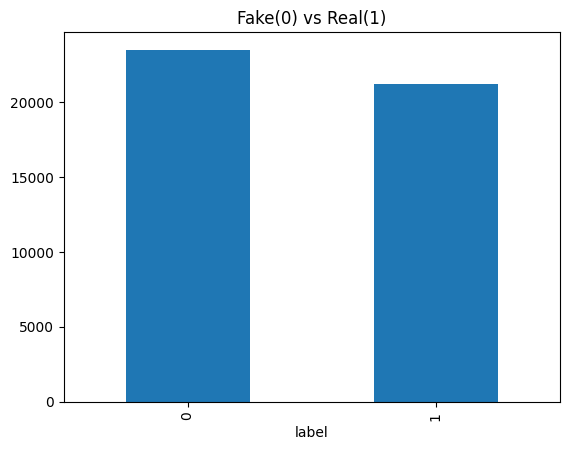

label
0    230.586634
1    226.166329
Name: text_len, dtype: float64

In [6]:
import matplotlib.pyplot as plt

# label distribution
df['label'].value_counts().plot(kind='bar', title='Fake(0) vs Real(1)')
plt.show()

# text length
df['text_len'] = df['clean_text'].apply(lambda x: len(x.split()))
df['text_len'].describe()

df.groupby('label')['text_len'].mean()

In [7]:
import re

def remove_source_tags(text):
    text = re.sub(r'^\(?reuters\)?\s*[-–]?\s*', '', text)
    text = re.sub(r'\breuters\b', '', text)
    return text.strip()

df['clean_text'] = df['clean_text'].apply(remove_source_tags)
df[['text', 'clean_text']].head()

,text,clean_text
0,"21st Century Wire says Ben Stein, reputable pr...",st century wire say ben stein reputable profes...
1,WASHINGTON (Reuters) - U.S. President Donald T...,washington u president donald trump removed c...
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,puerto rico governor ricardo rossello said wed...
3,"On Monday, Donald Trump once again embarrassed...",monday donald trump embarrassed country accide...
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",glasgow scotland u presidential candidate go ...


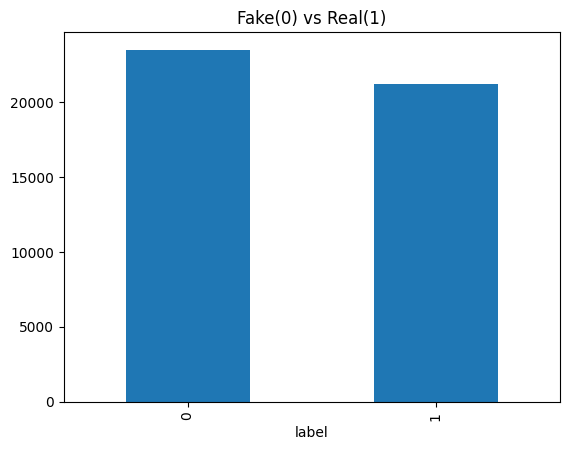

label
0    230.571088
1    224.841073
Name: text_len, dtype: float64

In [8]:
import matplotlib.pyplot as plt

# label distribution
df['label'].value_counts().plot(kind='bar', title='Fake(0) vs Real(1)')
plt.show()

# text length
df['text_len'] = df['clean_text'].apply(lambda x: len(x.split()))
df['text_len'].describe()

df.groupby('label')['text_len'].mean()

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Train shape: (35751, 5000)
Test shape: (8938, 5000)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds))
    print()

results

--- Logistic Regression ---
Accuracy: 0.9819
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      4696
           1       0.98      0.99      0.98      4242

    accuracy                           0.98      8938
   macro avg       0.98      0.98      0.98      8938
weighted avg       0.98      0.98      0.98      8938


--- Naive Bayes ---
Accuracy: 0.9398
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      4696
           1       0.94      0.93      0.94      4242

    accuracy                           0.94      8938
   macro avg       0.94      0.94      0.94      8938
weighted avg       0.94      0.94      0.94      8938


--- Linear SVM ---
Accuracy: 0.9894
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.99      0.99      0.99      4242

    accuracy                           0.99      8938
   macro

c:\Users\om.ak\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:13:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost ---
Accuracy: 0.9881
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.99      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938




{'Logistic Regression': 0.981875139852316,
 'Naive Bayes': 0.9398075632132468,
 'Linear SVM': 0.9893712239874692,
 'Random Forest': 0.9860147684045648,
 'XGBoost': 0.9881405236070709}

In [14]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100, random_state=42)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

print("Train shape:", X_train_svd.shape)
print("Test shape:", X_test_svd.shape)
print("Explained variance:", svd.explained_variance_ratio_.sum())

Train shape: (35751, 100)
Test shape: (8938, 100)
Explained variance: 0.23646487300543415


In [15]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42)
mlp.fit(X_train_tfidf, y_train)
preds_mlp = mlp.predict(X_test_tfidf)

acc_mlp = accuracy_score(y_test, preds_mlp)
print("MLP Accuracy:", acc_mlp)
print(classification_report(y_test, preds_mlp))

results["MLP (Neural Net)"] = acc_mlp
results

MLP Accuracy: 0.9875811143432536
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.99      0.98      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



{'Logistic Regression': 0.981875139852316,
 'Naive Bayes': 0.9398075632132468,
 'Linear SVM': 0.9893712239874692,
 'Random Forest': 0.9860147684045648,
 'XGBoost': 0.9881405236070709,
 'MLP (Neural Net)': 0.9875811143432536}

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(LinearSVC(max_iter=5000), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_tfidf, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

best_svm = grid.best_estimator_
preds_best = best_svm.predict(X_test_tfidf)
print("Test Accuracy:", accuracy_score(y_test, preds_best))
print(classification_report(y_test, preds_best))

Best params: {'C': 1}
Best CV score: 0.9884479005821476
Test Accuracy: 0.9893712239874692
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.99      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



In [19]:
import numpy as np
from lime.lime_text import LimeTextExplainer
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(tfidf, best_svm)

def predict_proba_wrapper(texts):
    scores = best_svm.decision_function(tfidf.transform(texts))
    probs_class1 = 1 / (1 + np.exp(-scores))  # sigmoid to fake it as probability
    probs_class0 = 1 - probs_class1
    return np.vstack([probs_class0, probs_class1]).T

class_names = ['Fake', 'Real']
explainer = LimeTextExplainer(class_names=class_names)

idx = 5
sample_text = X_test.iloc[idx]
exp = explainer.explain_instance(sample_text, predict_proba_wrapper, num_features=10)

for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")


old: -0.0958
via: -0.0522
photo: -0.0341
month: 0.0291
afghan: 0.0279
guilty: 0.0274
even: -0.0273
year: 0.0240
wednesday: 0.0237
yearold: 0.0235


In [20]:
print(df['subject'].value_counts())

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


In [21]:
print(pd.crosstab(df['subject'], df['label']))

label               0      1
subject                     
Government News  1570      0
Middle-east       778      0
News             9050      0
US_News           783      0
left-news        4459      0
politics         6838      0
politicsNews        0  11220
worldnews           0   9991


In [22]:
print(df['date'].head(10))
print(df['date'].dtype)

0      February 13, 2017
1         April 5, 2017 
2    September 27, 2017 
3           May 22, 2017
4         June 24, 2016 
5          June 22, 2016
6           Feb 19, 2017
7            Mar 8, 2016
8     December 13, 2017 
9           May 4, 2016 
Name: date, dtype: str
str


In [23]:
df['parsed_date'] = pd.to_datetime(df['date'].str.strip(), format='mixed', errors='coerce')
print(df['parsed_date'].isnull().sum())
print(df['parsed_date'].min(), df['parsed_date'].max())

10
2015-03-31 00:00:00 2018-02-19 00:00:00


In [24]:
df_dated = df.dropna(subset=['parsed_date']).sort_values('parsed_date').reset_index(drop=True)

split_idx = int(len(df_dated) * 0.8)
train_dated = df_dated.iloc[:split_idx]
test_dated = df_dated.iloc[split_idx:]

print("Train date range:", train_dated['parsed_date'].min(), "-", train_dated['parsed_date'].max())
print("Test date range:", test_dated['parsed_date'].min(), "-", test_dated['parsed_date'].max())
print("Train label dist:\n", train_dated['label'].value_counts())
print("Test label dist:\n", test_dated['label'].value_counts())

Train date range: 2015-03-31 00:00:00 - 2017-10-12 00:00:00
Test date range: 2017-10-12 00:00:00 - 2018-02-19 00:00:00
Train label dist:
 label
0    22074
1    13669
Name: count, dtype: int64
Test label dist:
 label
1    7542
0    1394
Name: count, dtype: int64


In [25]:
X_train_time = train_dated['clean_text']
y_train_time = train_dated['label']
X_test_time = test_dated['clean_text']
y_test_time = test_dated['label']

tfidf_time = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_time_tfidf = tfidf_time.fit_transform(X_train_time)
X_test_time_tfidf = tfidf_time.transform(X_test_time)

svm_time = LinearSVC(C=1, max_iter=5000)
svm_time.fit(X_train_time_tfidf, y_train_time)
preds_time = svm_time.predict(X_test_time_tfidf)

print("Time-based split Accuracy:", accuracy_score(y_test_time, preds_time))
print(classification_report(y_test_time, preds_time))

Time-based split Accuracy: 0.9801924798567592
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1394
           1       1.00      0.98      0.99      7542

    accuracy                           0.98      8936
   macro avg       0.95      0.98      0.96      8936
weighted avg       0.98      0.98      0.98      8936



In [26]:
import joblib

joblib.dump(best_svm, '../models/fake_news_svm_model.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')

print("Model and vectorizer saved!")

Model and vectorizer saved!


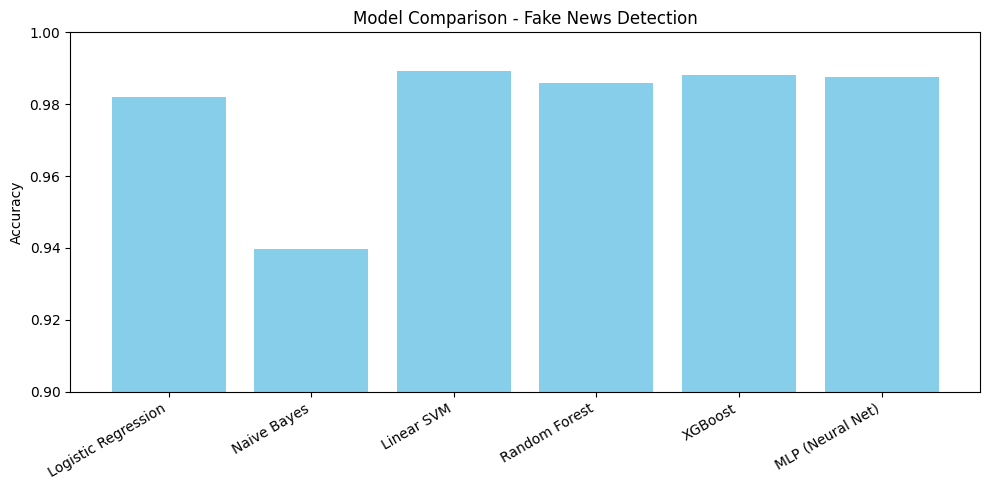

In [27]:
plt.figure(figsize=(10,5))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.ylabel('Accuracy')
plt.title('Model Comparison - Fake News Detection')
plt.xticks(rotation=30, ha='right')
plt.ylim(0.9, 1.0)
plt.tight_layout()
plt.savefig('../images/model_comparison.png')
plt.show()

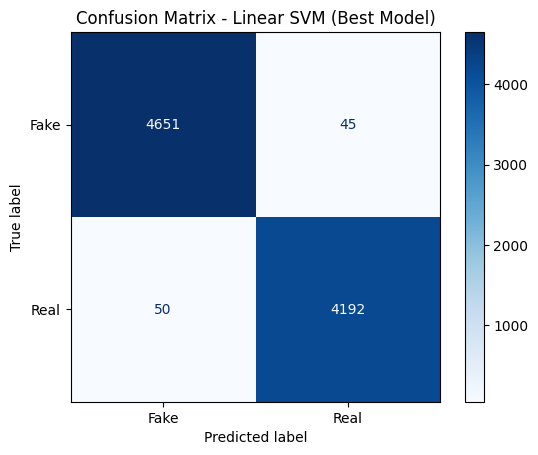

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, preds_best, display_labels=['Fake','Real'], cmap='Blues')
plt.title('Confusion Matrix - Linear SVM (Best Model)')
plt.savefig('../images/confusion_matrix.png')
plt.show()

## Summary

- **Dataset:** Kaggle Fake and Real News Dataset (~44K articles, cleaned to remove 209 duplicates)
- **Leakage fixes:** Removed "Reuters" source tags from text; identified subject column as a full leakage source (not used as a feature)
- **Best model:** Linear SVM (TF-IDF, 1-2 grams) — 98.94% test accuracy
- **Tuning:** GridSearchCV confirmed C=1 as optimal (no improvement over default)
- **Explainability:** LIME used to inspect per-prediction word contributions
- **Generalization:** Time-based split (train on older articles, test on newer) gave 98.02% accuracy, confirming the model generalizes beyond memorized patterns
- **Artifacts saved:** `fake_news_svm_model.pkl`, `tfidf_vectorizer.pkl`